# Primer Parcial - Machine Learning 1
## Análisis Exploratorio de Datos

### Pregunta de investigación

¿Qué factores académicos disponibles después del primer parcial permiten estimar
la probabilidad de que un estudiante de Métodos Numéricos alcance una firma final
de 71 puntos o más, considerando su rendimiento actual, su firma previa, su carga
académica y su rendimiento en el ciclo anterior?

### Objetivo del análisis exploratorio

El objetivo de este análisis es estudiar la relación entre las características
académicas de los estudiantes y la variable `exonera`, identificando patrones,
diferencias entre grupos y posibles variables relevantes para el posterior
modelado.

### Nota sobre recuperatorios

Aunque el reglamento permite mejorar la firma mediante el primer recuperatorio,
en la cohorte objetivo del segundo ciclo de 2025 no se registran puntajes distintos
de cero en `Primer.Rec`.

Por este motivo, el recuperatorio no se incorpora como predictor en el modelo
actual. Su efecto sí está presente indirectamente en la construcción de la firma
previa proveniente del ciclo anterior.

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Carga del dataset procesado

Se carga el dataset obtenido durante la etapa de preprocesamiento, que contiene
las variables seleccionadas para el análisis y la variable objetivo `exonera`.

In [2]:
ruta = "../data/dataset_metodos_numericos_modelo.csv"

df = pd.read_csv(ruta)

df.head()

,carrera,primer_parcial,firma_previa,cantidad_materias_actual,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,exonera
0,Ing. Geográfica,0,40,7,5,1,0.200000,0
1,Ing. Geográfica,0,40,7,5,1,0.200000,0
2,Ing. Industrial,0,53,7,7,3,0.428571,0
3,Ing. Industrial,0,53,7,7,3,0.428571,0
4,Ing. Civil,0,34,6,6,4,0.666667,0


In [3]:
print("Dimensiones:", df.shape)
df.info()

Dimensiones: (260, 8)
<class 'pandas.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   carrera                      260 non-null    str    
 1   primer_parcial               260 non-null    int64  
 2   firma_previa                 260 non-null    int64  
 3   cantidad_materias_actual     260 non-null    int64  
 4   cantidad_materias_anterior   260 non-null    int64  
 5   materias_aprobadas_anterior  260 non-null    int64  
 6   tasa_aprobacion_anterior     260 non-null    float64
 7   exonera                      260 non-null    int64  
dtypes: float64(1), int64(6), str(1)
memory usage: 16.4 KB


## 3. Distribución de la variable objetivo

Se analiza la cantidad y proporción de estudiantes que alcanzaron una firma
igual o superior a 71 puntos.

Esta revisión permite identificar si existe desbalance entre las clases.

In [4]:
distribucion = df["exonera"].value_counts().sort_index()

porcentajes = (
    df["exonera"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Cantidad:")
print(distribucion)

print("\nPorcentaje:")
print(porcentajes.round(2))

Cantidad:
exonera
0    226
1     34
Name: count, dtype: int64

Porcentaje:
exonera
0    86.92
1    13.08
Name: proportion, dtype: float64


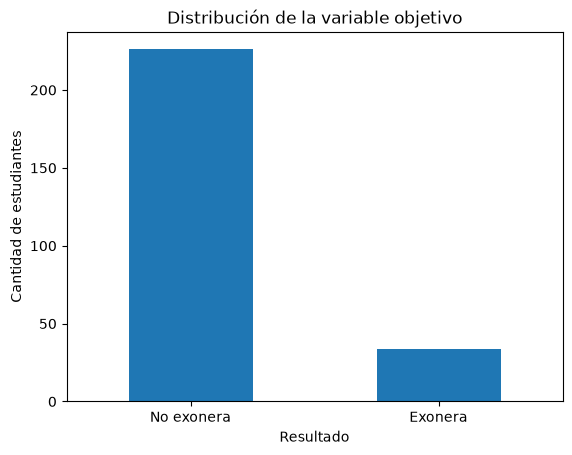

In [5]:
etiquetas = ["No exonera", "Exonera"]

distribucion.plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de estudiantes")
plt.xticks([0, 1], etiquetas, rotation=0)
plt.show()

### Observación

La variable objetivo presenta un desbalance importante. La mayoría de los
estudiantes no alcanza una firma de 71 puntos, mientras que una proporción
menor logra exonerar.

Este desbalance deberá tenerse en cuenta posteriormente al evaluar el modelo,
ya que la exactitud por sí sola podría resultar engañosa.

## 4. Comparación de variables numéricas según el resultado

Se comparan las características académicas de los estudiantes que alcanzaron
una firma de 71 puntos o más con aquellos que no lo hicieron.

In [6]:
variables_numericas = [
    "primer_parcial",
    "firma_previa",
    "cantidad_materias_actual",
    "cantidad_materias_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior"
]

df.groupby("exonera")[variables_numericas].mean().round(2)

,primer_parcial,firma_previa,cantidad_materias_actual,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior
exonera,,,,,,
0,20.74,42.17,5.93,5.73,2.50,0.44
1,73.71,44.29,6.71,6.65,4.35,0.64


In [7]:
df.groupby("exonera")[variables_numericas].median().round(2)

,primer_parcial,firma_previa,cantidad_materias_actual,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior
exonera,,,,,,
0,11.0,41.0,6.0,6.0,2.0,0.50
1,69.0,44.0,7.0,7.0,4.0,0.67


## 5. Relación entre el primer parcial y la exoneración

Se compara el puntaje obtenido en el primer parcial entre los estudiantes que
alcanzaron una firma de 71 puntos o más y aquellos que no alcanzaron dicho
umbral.

El primer parcial representa el rendimiento académico actual disponible en el
momento definido para realizar la predicción.

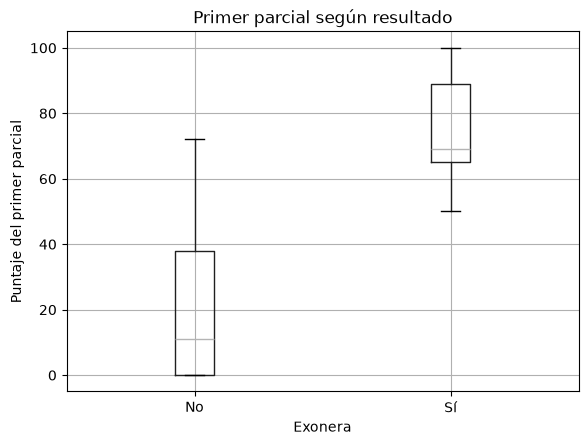

In [8]:
df.boxplot(
    column="primer_parcial",
    by="exonera"
)

plt.title("Primer parcial según resultado")
plt.suptitle("")
plt.xlabel("Exonera")
plt.ylabel("Puntaje del primer parcial")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

## 6. Relación entre la firma previa y la exoneración

Se analiza si los estudiantes que comienzan el período con una firma previa
más alta presentan una mayor tendencia a alcanzar el umbral de 71 puntos.

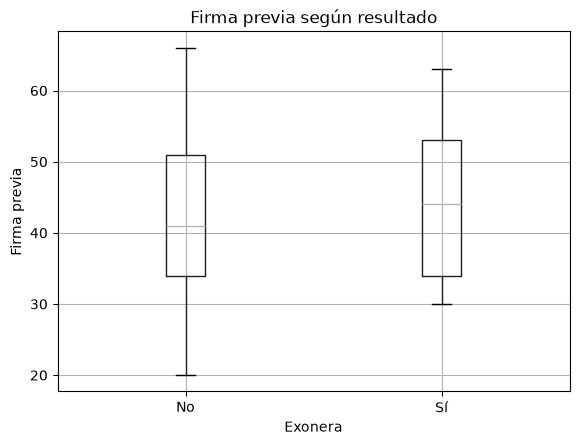

In [9]:
df.boxplot(
    column="firma_previa",
    by="exonera"
)

plt.title("Firma previa según resultado")
plt.suptitle("")
plt.xlabel("Exonera")
plt.ylabel("Firma previa")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

In [10]:
df.groupby("exonera")["firma_previa"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
exonera,,,,,,,,
0,226.0,42.17,10.49,20.0,34.0,41.0,51.0,66.0
1,34.0,44.29,11.16,30.0,34.0,44.0,53.0,63.0


## 7. Relación entre el rendimiento anterior y la exoneración

Se analiza si el desempeño académico del ciclo anterior presenta diferencias
entre los estudiantes que alcanzan una firma de 71 puntos o más y aquellos que
no lo hacen.

Se consideran principalmente la tasa de aprobación y la cantidad de materias
aprobadas durante el ciclo anterior.

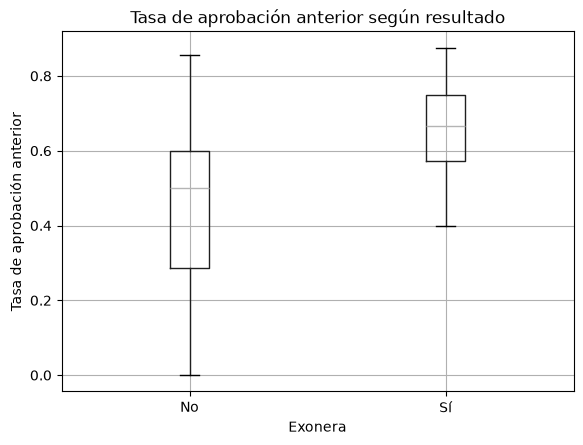

In [11]:
df.boxplot(
    column="tasa_aprobacion_anterior",
    by="exonera"
)

plt.title("Tasa de aprobación anterior según resultado")
plt.suptitle("")
plt.xlabel("Exonera")
plt.ylabel("Tasa de aprobación anterior")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

In [12]:
df.groupby("exonera")["tasa_aprobacion_anterior"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
exonera,,,,,,,,
0,226.0,0.44,0.22,0.0,0.29,0.50,0.60,0.86
1,34.0,0.64,0.16,0.4,0.57,0.67,0.75,0.88


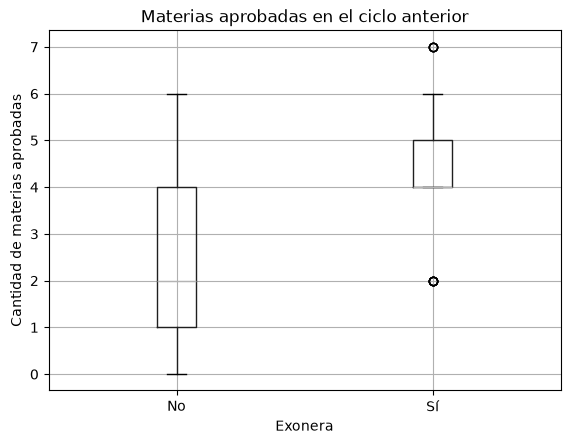

In [13]:
df.boxplot(
    column="materias_aprobadas_anterior",
    by="exonera"
)

plt.title("Materias aprobadas en el ciclo anterior")
plt.suptitle("")
plt.xlabel("Exonera")
plt.ylabel("Cantidad de materias aprobadas")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

## 8. Relación entre la carga académica y la exoneración

Se compara la cantidad de materias cursadas en el período actual y en el ciclo
anterior entre ambos grupos.

El objetivo es evaluar si una mayor carga académica parece asociarse con una
menor o mayor probabilidad de alcanzar la firma requerida.

In [14]:
df.groupby("exonera")[
    [
        "cantidad_materias_actual",
        "cantidad_materias_anterior"
    ]
].describe().round(2)

cantidad_materias_actual                                       \
                           count  mean   std  min  25%  50%  75%  max   
exonera                                                                 
0                          226.0  5.93  1.38  2.0  5.0  6.0  7.0  9.0   
1                           34.0  6.71  1.34  4.0  6.0  7.0  8.0  9.0   

        cantidad_materias_anterior                                       
                             count  mean   std  min  25%  50%  75%  max  
exonera                                                                  
0                            226.0  5.73  1.36  2.0  5.0  6.0  7.0  8.0  
1                             34.0  6.65  1.15  5.0  6.0  7.0  8.0  8.0

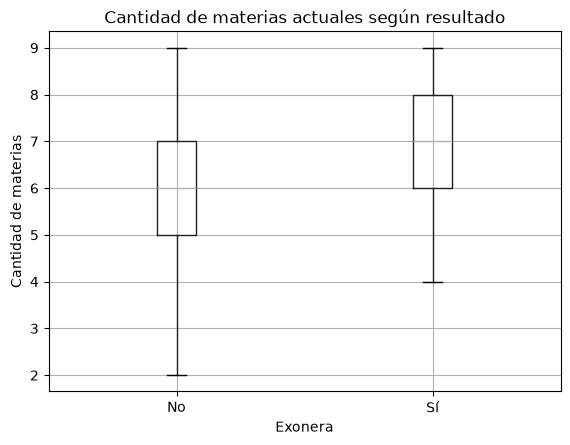

In [15]:
df.boxplot(
    column="cantidad_materias_actual",
    by="exonera"
)

plt.title("Cantidad de materias actuales según resultado")
plt.suptitle("")
plt.xlabel("Exonera")
plt.ylabel("Cantidad de materias")
plt.xticks([1, 2], ["No", "Sí"])
plt.show()

## 9. Exoneración según carrera

Se analiza la proporción de estudiantes que alcanza una firma de 71 puntos o
más en cada carrera.

Debido a que algunas carreras poseen pocos estudiantes, los porcentajes se
interpretan junto con la cantidad total de casos.

In [16]:
resumen_carrera = (
    df.groupby("carrera")
    .agg(
        estudiantes=("exonera", "count"),
        exoneran=("exonera", "sum"),
        tasa_exoneracion=("exonera", "mean")
    )
    .reset_index()
)

resumen_carrera["tasa_exoneracion"] = (
    resumen_carrera["tasa_exoneracion"] * 100
).round(2)

resumen_carrera.sort_values(
    "tasa_exoneracion",
    ascending=False
)

,carrera,estudiantes,exoneran,tasa_exoneracion
0,Ing. Civil,108,24,22.22
1,Ing. Electromecánica,70,8,11.43
3,Ing. Geográfica,24,2,8.33
2,Ing. Electrónica,8,0,0.00
4,Ing. Industrial,20,0,0.00
5,Ing. Mecatrónica,18,0,0.00
6,Ing. Mecánica,12,0,0.00


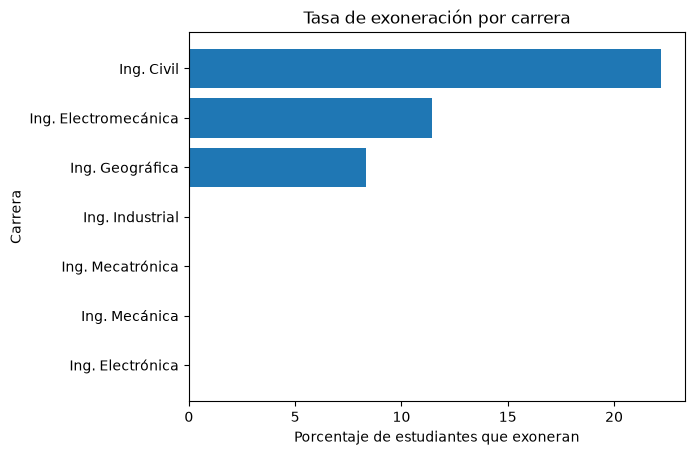

In [17]:
resumen_carrera_ordenado = resumen_carrera.sort_values(
    "tasa_exoneracion"
)

plt.barh(
    resumen_carrera_ordenado["carrera"],
    resumen_carrera_ordenado["tasa_exoneracion"]
)

plt.title("Tasa de exoneración por carrera")
plt.xlabel("Porcentaje de estudiantes que exoneran")
plt.ylabel("Carrera")
plt.show()

## 10. Correlación entre variables numéricas

Se analiza la correlación entre las variables numéricas para identificar
relaciones fuertes y posibles redundancias antes del modelado.

Debe tenerse en cuenta que la correlación mide asociación lineal y no implica
causalidad.

correlacion = df[
    variables_numericas + ["exonera"]
].corr()

correlacion.round(2)

In [18]:
correlacion = df[
    variables_numericas + ["exonera"]
].corr()

correlacion.round(2)

,primer_parcial,firma_previa,cantidad_materias_actual,cantidad_materias_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,exonera
primer_parcial,1.00,0.14,0.20,0.15,0.38,0.32,0.65
firma_previa,0.14,1.00,0.17,-0.26,0.10,0.22,0.07
cantidad_materias_actual,0.20,0.17,1.00,0.16,0.38,0.34,0.19
cantidad_materias_anterior,0.15,-0.26,0.16,1.00,0.46,0.06,0.23
materias_aprobadas_anterior,0.38,0.10,0.38,0.46,1.00,0.89,0.40
tasa_aprobacion_anterior,0.32,0.22,0.34,0.06,0.89,1.00,0.30
exonera,0.65,0.07,0.19,0.23,0.40,0.30,1.00


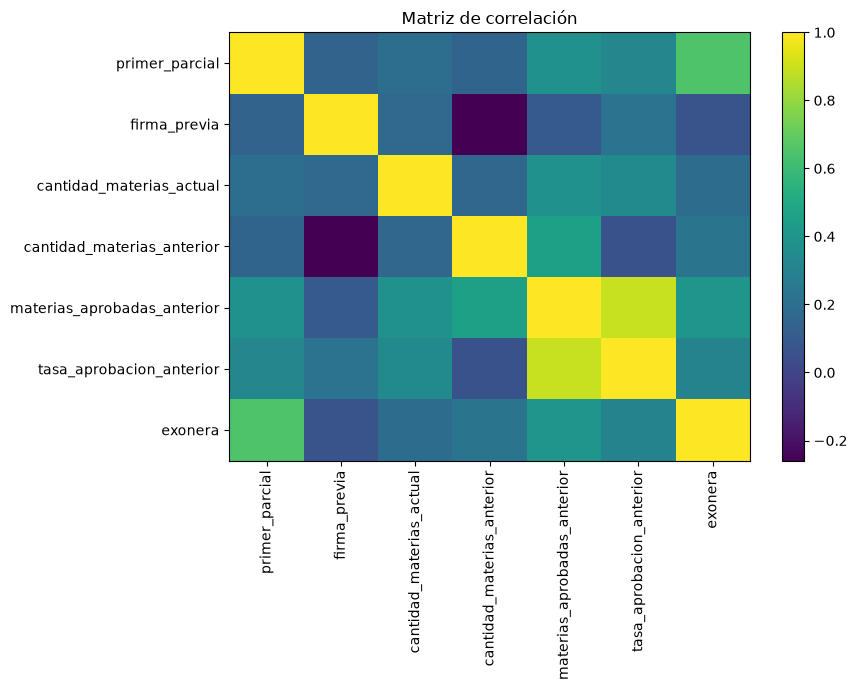

In [19]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlacion,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.index)),
    correlacion.index
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

## 11. Análisis de los estudiantes con primer parcial igual a cero

Dado que el valor cero podría representar una ausencia o una calificación real
de cero, se analiza por separado su relación con la variable objetivo.

Aunque no es posible distinguir ambas situaciones, el valor puede contener
información relevante para la predicción.

In [20]:
df["primer_parcial_cero"] = (df["primer_parcial"] == 0).astype(int)

pd.crosstab(
    df["primer_parcial_cero"],
    df["exonera"],
    margins=True
)

exonera,0,1,All
primer_parcial_cero,,,
0,138,34,172
1,88,0,88
All,226,34,260


In [21]:
pd.crosstab(
    df["primer_parcial_cero"],
    df["exonera"],
    normalize="index"
).round(3) * 100

exonera,0,1
primer_parcial_cero,,
0,80.2,19.8
1,100.0,0.0


## 12. Principales hallazgos del análisis exploratorio

El análisis exploratorio muestra que el rendimiento en el primer parcial es la
variable que presenta la relación más fuerte con alcanzar una firma de 71 puntos
o más.

Los estudiantes que exoneran presentan un puntaje promedio considerablemente
mayor en el primer parcial que aquellos que no exoneran.

También se observa una relación entre el rendimiento académico del ciclo anterior
y la exoneración. Tanto la cantidad de materias aprobadas como la tasa de aprobación
del ciclo anterior son mayores, en promedio, entre los estudiantes que alcanzan
el umbral requerido.

La firma previa presenta poca diferencia entre ambos grupos, por lo que inicialmente
parece aportar menos información predictiva.

Por otra parte, las variables `materias_aprobadas_anterior` y
`tasa_aprobacion_anterior` presentan una correlación elevada entre sí, por lo que
se deberá evitar incluir ambas sin evaluar su posible redundancia.

Un resultado relevante es que ninguno de los estudiantes con primer parcial igual
a cero logró exonerar. Aunque el dataset no permite diferenciar entre una ausencia
y una calificación real de cero, este valor parece contener información importante
para la predicción.

Finalmente, se observan diferencias entre carreras, aunque estas deben interpretarse
con precaución debido al tamaño reducido de algunas categorías.